In [ ]:
import pandas as pd
import os



df = pd.read_csv('../data/BTC-USD_historical.csv' )


df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


df['Date'] = pd.to_datetime(df['Date'])


df['Returns'] = df['Close'].pct_change()
# 7-day rolling standard deviation
df['Volatility'] = df['Returns'].rolling(window=7).std()

#Dropping the first few rows where Volatility is NaN
df.dropna(inplace=True)

print("Cleaned Financial Data:")
df.head()

Cleaned Financial Data:


,Date,Close,High,Low,Open,Volume,Returns,Volatility
7,2023-01-08,17091.14453,17091.14453,16924.05078,16954.14648,9768827914,0.008025,0.004817
8,2023-01-09,17196.55469,17389.95703,17093.99219,17093.99219,18624736866,0.006168,0.004886
9,2023-01-10,17446.29297,17484.72070,17162.99023,17192.94922,15808338949,0.014523,0.005659
10,2023-01-11,17934.89648,17934.89648,17337.99414,17446.35938,18372283782,0.028006,0.009956
11,2023-01-12,18869.58789,19030.08789,17995.20313,18117.59375,34971338710,0.052116,0.017995


<Axes: xlabel='Date'>

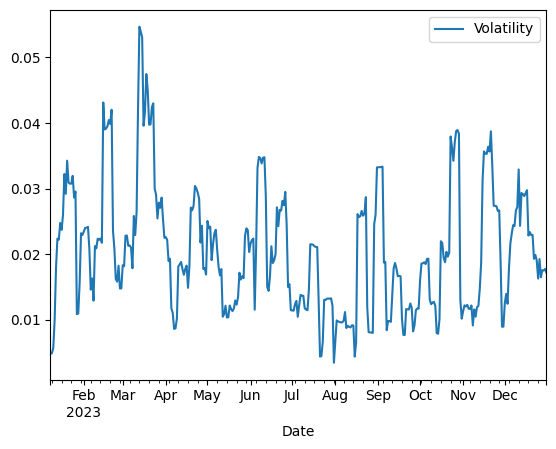

In [ ]:
df[['Date', 'Volatility']].plot(x='Date')


In [4]:
import requests

# 1. Get Sentiment Data
fng_url = "https://api.alternative.me/fng/?limit=1000&format=json"
response = requests.get(fng_url).json()
fng_df = pd.DataFrame(response['data'])

# 2. Clean Sentiment Data
fng_df['Date'] = pd.to_datetime(fng_df['timestamp'], unit='s')
fng_df['FNG_Value'] = fng_df['value'].astype(int)
fng_df = fng_df[['Date', 'FNG_Value', 'value_classification']]

# 3. MERGE
# We ensure both Dates are normalized to midnight (no time)
df['Date'] = df['Date'].dt.normalize()
fng_df['Date'] = fng_df['Date'].dt.normalize()

research_df = pd.merge(df, fng_df, on='Date', how='inner')

print(f"✅ Success! You have {len(research_df)} days of matched data.")
research_df.head()

✅ Success! You have 172 days of matched data.


C:\Users\Anura\AppData\Local\Temp\ipykernel_9620\445741250.py:9: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  fng_df['Date'] = pd.to_datetime(fng_df['timestamp'], unit='s')


,Date,Close,High,Low,Open,Volume,Returns,Volatility,FNG_Value,value_classification
0,2023-07-13,31476.04883,31814.51563,30268.35156,30387.48828,23686079548,0.035681,0.014629,57,Greed
1,2023-07-14,30334.06836,31582.25391,29966.38672,31474.72070,20917902660,-0.036281,0.021506,60,Greed
2,2023-07-15,30295.80664,30407.78125,30263.46289,30331.78320,8011667756,-0.001261,0.021502,56,Greed
3,2023-07-16,30249.13281,30437.56055,30089.66992,30297.47266,8516564470,-0.001541,0.021441,57,Greed
4,2023-07-17,30145.88867,30336.40039,29685.78320,30249.62695,13240156074,-0.003413,0.021210,54,Neutral


In [5]:
fng_df.head()

,Date,FNG_Value,value_classification
0,2026-04-08,17,Extreme Fear
1,2026-04-07,11,Extreme Fear
2,2026-04-06,13,Extreme Fear
3,2026-04-05,12,Extreme Fear
4,2026-04-04,11,Extreme Fear


In [18]:
df['Volatility'].corr(fng_df['FNG_Value'])

np.float64(-0.16712062457928017)

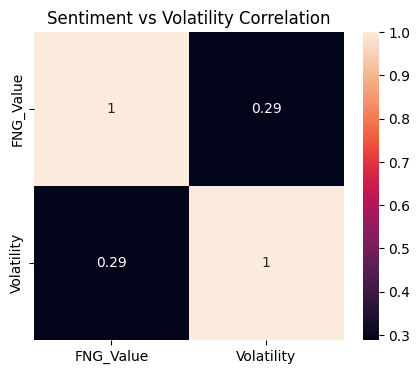

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = research_df[['FNG_Value', 'Volatility']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True)
plt.title("Sentiment vs Volatility Correlation")
plt.show()

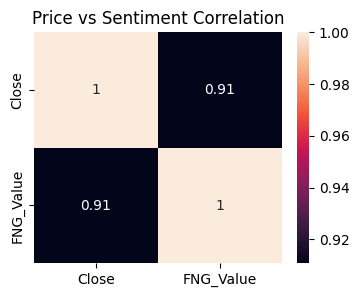

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = research_df[['Close', 'FNG_Value']].corr()

plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True)
plt.title("Price vs Sentiment Correlation")
plt.show()

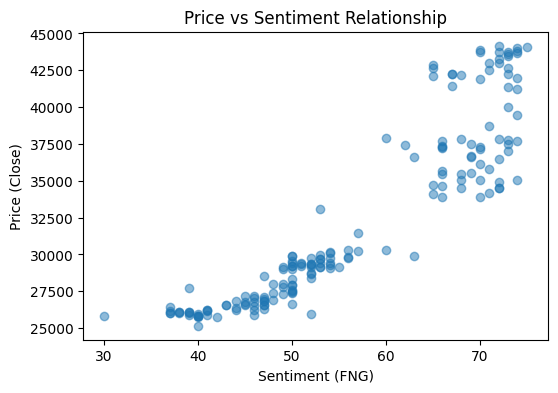

In [8]:
plt.figure(figsize=(6,4))

plt.scatter(research_df['FNG_Value'], research_df['Close'], alpha=0.5)

plt.xlabel("Sentiment (FNG)")
plt.ylabel("Price (Close)")
plt.title("Price vs Sentiment Relationship")

plt.show()

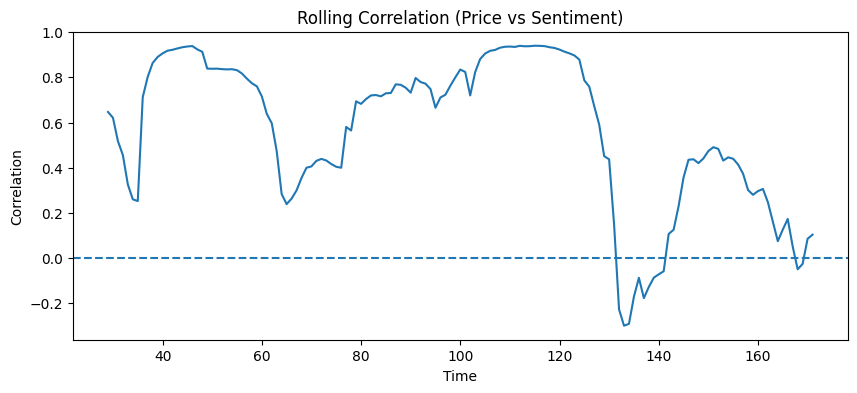

In [9]:
rolling_corr = research_df['Close'].rolling(30).corr(research_df['FNG_Value'])

plt.figure(figsize=(10,4))
plt.plot(rolling_corr)

plt.title("Rolling Correlation (Price vs Sentiment)")
plt.xlabel("Time")
plt.ylabel("Correlation")
plt.axhline(0, linestyle='--')

plt.show()

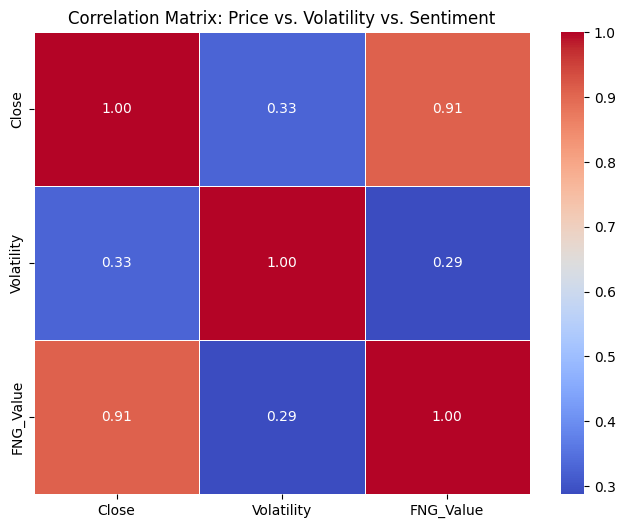

Correlation Values:
Close         0.329297
Volatility    1.000000
FNG_Value     0.287680
Name: Volatility, dtype: float64


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix
# We focus on Close Price, Volatility, and FNG_Value
corr_matrix = research_df[['Close', 'Volatility', 'FNG_Value']].corr()

# 2. Plotting the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Price vs. Volatility vs. Sentiment')
plt.show()

print("Correlation Values:")
print(corr_matrix['Volatility'])

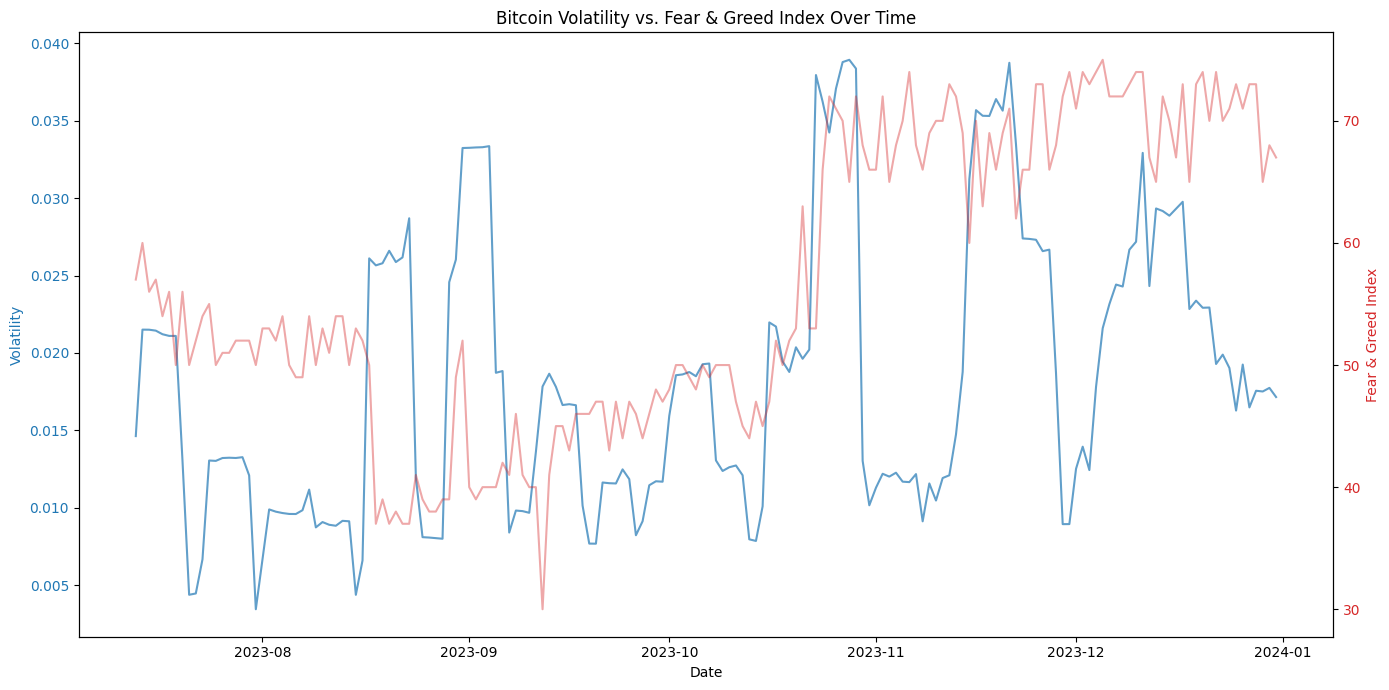

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Volatility on the left Y-axis
ax1.set_xlabel('Date')
ax1.set_ylabel('Volatility', color='tab:blue')
ax1.plot(research_df['Date'], research_df['Volatility'], color='tab:blue', label='7-Day Volatility', alpha=0.7)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second Y-axis for Sentiment
ax2 = ax1.twinx()
ax2.set_ylabel('Fear & Greed Index', color='tab:red')
ax2.plot(research_df['Date'], research_df['FNG_Value'], color='tab:red', label='F&G Index', alpha=0.4)
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Bitcoin Volatility vs. Fear & Greed Index Over Time')
fig.tight_layout()
plt.show()

In [12]:
# 1. Create Lagged Features
# Shift sentiment by 1, 3, and 5 days to see if it predicts FUTURE volatility
research_df['FNG_Lag1'] = research_df['FNG_Value'].shift(1)
research_df['FNG_Lag3'] = research_df['FNG_Value'].shift(3)

# 2. Calculate Correlation with these Lags
lag_corr = research_df[['Volatility', 'FNG_Value', 'FNG_Lag1', 'FNG_Lag3']].corr()

print("Predictive Correlation (Lag Analysis):")
print(lag_corr['Volatility'])

Predictive Correlation (Lag Analysis):
Volatility    1.000000
FNG_Value     0.287680
FNG_Lag1      0.280140
FNG_Lag3      0.279748
Name: Volatility, dtype: float64


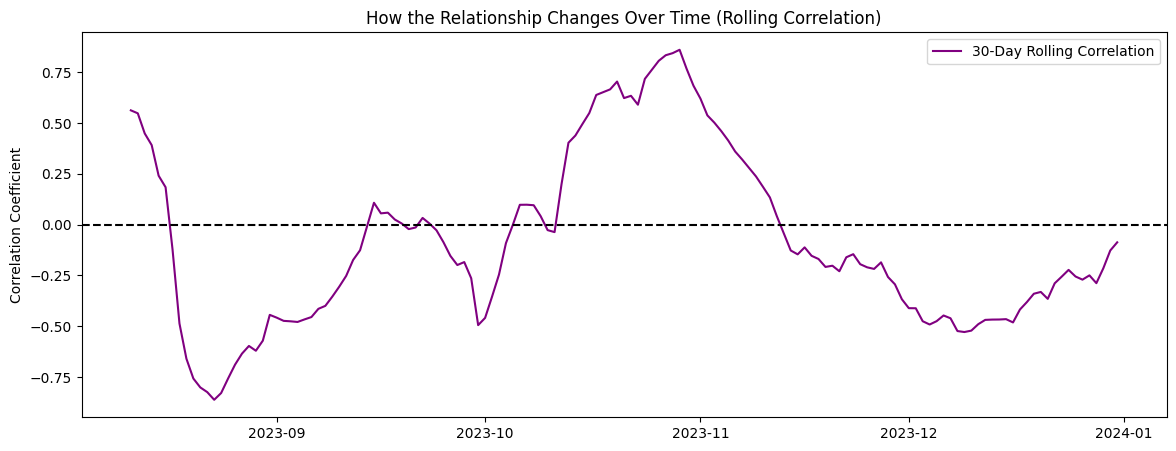

In [13]:
# Calculate rolling correlation over a 30-day window
research_df['Rolling_Corr'] = research_df['Volatility'].rolling(window=30).corr(research_df['FNG_Value'])

plt.figure(figsize=(14, 5))
plt.plot(research_df['Date'], research_df['Rolling_Corr'], color='purple', label='30-Day Rolling Correlation')
plt.axhline(y=0, color='black', linestyle='--') # Zero line
plt.title('How the Relationship Changes Over Time (Rolling Correlation)')
plt.ylabel('Correlation Coefficient')
plt.legend()
plt.show()

In [21]:
research_df.head()

,Date,Close,High,Low,Open,Volume,Returns,Volatility,FNG_Value,value_classification,FNG_Lag1,FNG_Lag3,Rolling_Corr
0,2023-07-13,31476.04883,31814.51563,30268.35156,30387.48828,23686079548,0.035681,0.014629,57,Greed,NaN,NaN,NaN
1,2023-07-14,30334.06836,31582.25391,29966.38672,31474.72070,20917902660,-0.036281,0.021506,60,Greed,57.0,NaN,NaN
2,2023-07-15,30295.80664,30407.78125,30263.46289,30331.78320,8011667756,-0.001261,0.021502,56,Greed,60.0,NaN,NaN
3,2023-07-16,30249.13281,30437.56055,30089.66992,30297.47266,8516564470,-0.001541,0.021441,57,Greed,56.0,57.0,NaN
4,2023-07-17,30145.88867,30336.40039,29685.78320,30249.62695,13240156074,-0.003413,0.021210,54,Neutral,57.0,60.0,NaN


In [14]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Prepare the data (X = Sentiment, y = Volatility)
# We need to reshape for scikit-learn
X = research_df['FNG_Value'].values.reshape(-1, 1)
y = research_df['Volatility'].values

# 2. Create and fit the model
model = LinearRegression()
model.fit(X, y)

# 3. Extract the "Research Coefficients"
intercept = model.intercept_
slope = model.coef_[0]
r_squared = model.score(X, y)

print(f"Regression Equation: Volatility = {intercept:.4f} + ({slope:.6f} * Sentiment)")
print(f"R-squared (Accuracy): {r_squared:.4f}")

Regression Equation: Volatility = 0.0061 + (0.000214 * Sentiment)
R-squared (Accuracy): 0.0828


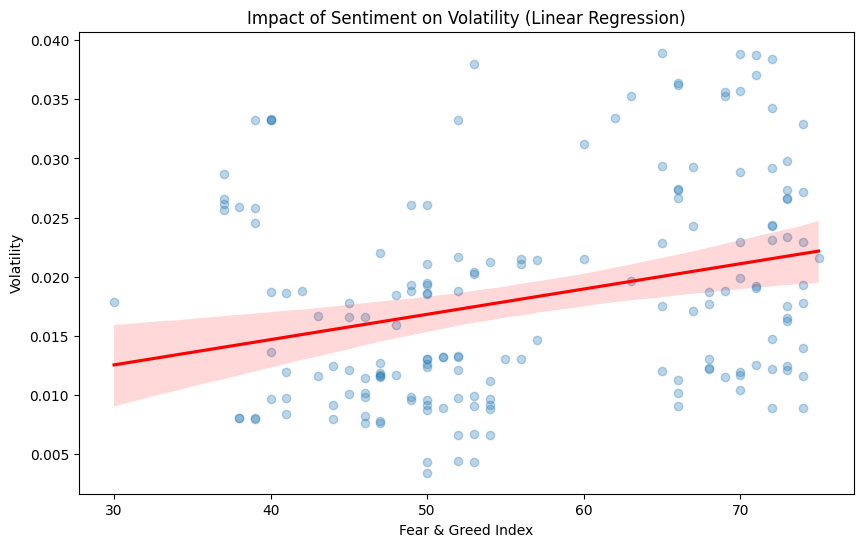

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(x='FNG_Value', y='Volatility', data=research_df, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Impact of Sentiment on Volatility (Linear Regression)')
plt.xlabel('Fear & Greed Index')
plt.ylabel('Volatility')
plt.show()

--- FINAL RESEARCH REGRESSION NUMBERS ---
Regression Equation: Volatility = 0.006147 + (0.000214 * Sentiment)
R-squared (Coefficient of Determination): 0.0828
----------------------------------------


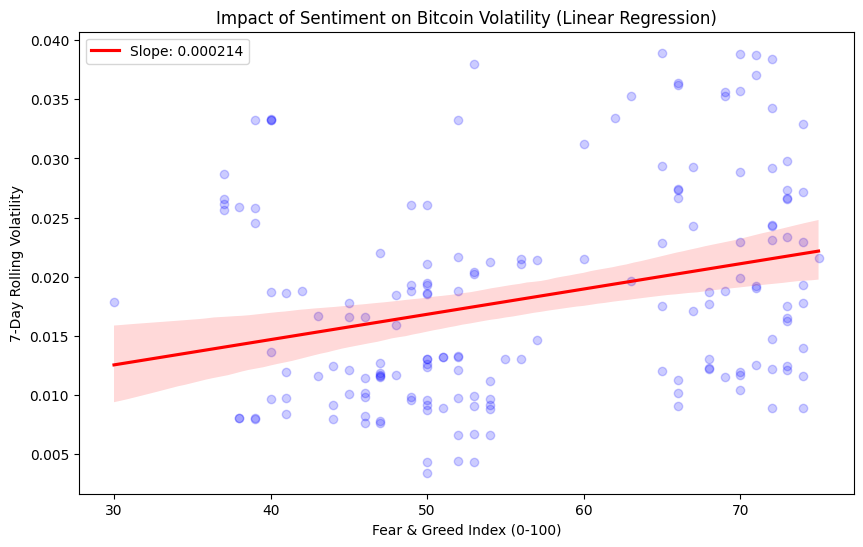

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# 1. Prepare Data
X = research_df['FNG_Value'].values.reshape(-1, 1)
y = research_df['Volatility'].values

# 2. Fit the Linear Regression Model
reg = LinearRegression()
reg.fit(X, y)

# 3. Calculate Key Research Metrics
intercept = reg.intercept_
slope = reg.coef_[0]
r_squared = r2_score(y, reg.predict(X))

# 4. Final Scientific Output
print("--- FINAL RESEARCH REGRESSION NUMBERS ---")
print(f"Regression Equation: Volatility = {intercept:.6f} + ({slope:.6f} * Sentiment)")
print(f"R-squared (Coefficient of Determination): {r_squared:.4f}")
print("-" * 40)

# 5. The "Regression Line" Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x='FNG_Value', y='Volatility', data=research_df, 
            scatter_kws={'alpha':0.2, 'color':'blue'}, 
            line_kws={'color':'red', 'label':f'Slope: {slope:.6f}'})

plt.title('Impact of Sentiment on Bitcoin Volatility (Linear Regression)')
plt.xlabel('Fear & Greed Index (0-100)')
plt.ylabel('7-Day Rolling Volatility')
plt.legend()
plt.show()